In [10]:
import numpy as np
from matplotlib import pyplot as plt
from scipy.integrate import solve_ivp
import matplotlib.colors as mcolors

### utils

In [2]:
# -----------------------------
# Dynamics hostile
# -----------------------------
def make_rhs_hostile(alpha, beta, epsilon, mu, k):
    def dxdt(t, x, n):
        # dx/dt = x(1-x)*(n-k)/(n+k)*(beta*x + alpha(1-x))
        return x * (1 - x) * (n - k) / (n + k) * (beta * x + alpha * (1 - x))
    
    def dndt(t, x, n):
        # dn/dt = epsilon * x - mu * n
        return epsilon * x - mu * n
    
    def f(t, y):
        x, n = y
        return [dxdt(t, x, n), dndt(t, x, n)]
    
    return f

In [17]:
# ---------------------------
# Dynamics coexistence scenario
# ---------------------------
def make_rhs_coexist(alpha, beta, epsilon, mu, k):
    def dxdt(t, x, n):
        # dx/dt = x(1-x)[ β ((n-k)/(n+k)) x + α(1-x) ]
        return x * (1 - x) * (beta * (n - k) / (n + k) * x + alpha * (1 - x))
    
    def dndt(t, x, n):
        # dn/dt = ε x - μ n
        return epsilon * x - mu * n
    
    def f(t, y):
        x, n = y
        return [dxdt(t, x, n), dndt(t, x, n)]
    
    return f

In [3]:
def add_arrows_to_line2D(line, n_arrows=3, arrowstyle='->', lw=1):
    """
    Add `n_arrows` arrows along a 2D line (Line2D object from plt.plot).
    Arrows are approximately equally spaced by arc length.
    """
    ax = line.axes
    x = line.get_xdata()
    y = line.get_ydata()
    color = line.get_color()

    N = len(x)
    if N < 2:
        return

    # cumulative arc length along the curve
    dx = np.diff(x)
    dy = np.diff(y)
    ds = np.sqrt(dx**2 + dy**2)
    s = np.concatenate(([0.0], np.cumsum(ds)))

    if s[-1] == 0:
        return  # completely flat / single point

    s_norm = s / s[-1]  # 0 -> 1 along the curve

    # where (in [0,1]) to place arrows (avoid very start and very end)
    targets = np.linspace(0.2, 0.8, n_arrows)

    for t in targets:
        # index where cumulative length first exceeds target
        idx = np.searchsorted(s_norm, t)
        if idx <= 0 or idx >= N:
            continue

        # arrow from point idx-1 to idx (direction of motion)
        x_start, y_start = x[idx-1], y[idx-1]
        x_end,   y_end   = x[idx],   y[idx]

        ax.annotate(
            "",
            xy=(x_end, y_end), xytext=(x_start, y_start),
            arrowprops=dict(
                arrowstyle=arrowstyle,
                color=color,
                lw=lw,
                shrinkA=0,
                shrinkB=0,
            ),
        )


In [4]:
def integrate_trajectory(y0, t_span=(0.0, 50.0), t_points=500):
    t_eval = np.linspace(t_span[0], t_span[1], t_points)
    sol = solve_ivp(f, t_span, y0, t_eval=t_eval, dense_output=False)
    return sol.t, sol.y  # t, [x(t), n(t)]

In [5]:
# ---------------------------
# Jacobian for hostile system
# ---------------------------
def jac_hostile(x, n, alpha, beta, epsilon, mu, k):
    # xdot = x(1-x)*((n-k)/(n+k)) * (β x + α(1-x))
    if n + k == 0:
        return np.array([[0.0, 0.0],
                         [0.0, -mu]])
    
    g = (n - k) / (n + k)
    h = beta * x + alpha * (1 - x)   # = α + (β-α)x

    # ∂ẋ/∂x = g * [ (1-2x)*h + x(1-x)*(β-α) ]
    dxdx = g * ((1 - 2*x)*h + x*(1 - x)*(beta - alpha))

    # ∂ẋ/∂n = x(1-x)*h * ∂g/∂n, with ∂g/∂n = 2k/(n+k)^2
    dgdn = 2 * k / (n + k)**2
    dxdn = x * (1 - x) * h * dgdn

    # ṅ = ε x - μ n
    dndx = epsilon
    dndn = -mu

    return np.array([[dxdx, dxdn],
                     [dndx, dndn]])

In [42]:
def x_star_plus(rho_hat, r):
    """
    x*_+ branch of the quadratic
    P(x; rho_hat, r) = rho_hat(2r-1)x^2 + (1-rho_hat*r)x - r = 0

    Returns NaN where:
      - discriminant < 0 (no real roots), or
      - x_+ is not in (0,1).
    """
    rho_hat = np.asarray(rho_hat)
    r = np.asarray(r)

    eps = 1e-9
    r_safe = np.where(np.abs(2*r-1) < eps, r + eps, r)

    disc = (1 - rho_hat*r_safe)**2 + 4*rho_hat*r_safe*(2*r_safe - 1)
    # Mask negative discriminant
    disc = np.where(disc >= 0, disc, np.nan)
    sqrt_disc = np.sqrt(disc)

    x_plus = (-(1 - rho_hat*r_safe) + sqrt_disc) / (2*rho_hat*(2*r_safe - 1))

    # Keep only interior roots
    x_plus = np.where((x_plus > 0) & (x_plus < 1), x_plus, np.nan)
    return x_plus

In [43]:
def rho_cap(r):
    """rho_hat_max(r) = rho_1(r) for r<=1/3; NaN otherwise."""
    r = np.asarray(r)
    disc = 4*r**2 - 6*r + 2
    cap = (3 - 4*r - 2*np.sqrt(disc)) / r
    cap = np.where(r <= 1/3, cap, np.nan)
    return cap

In [47]:
def rho_p(r):
    return ((3-4*r)+2*np.sqrt(4*r**2-6*r+2))/r

In [48]:
def rho_m(r):
    return ((3-4*r)-2*np.sqrt(4*r**2-6*r+2))/r

### 2. Hostile

### $\rho<k$

rho = 0.5 (should be < k=1.0 for hostile, sub-threshold regime)


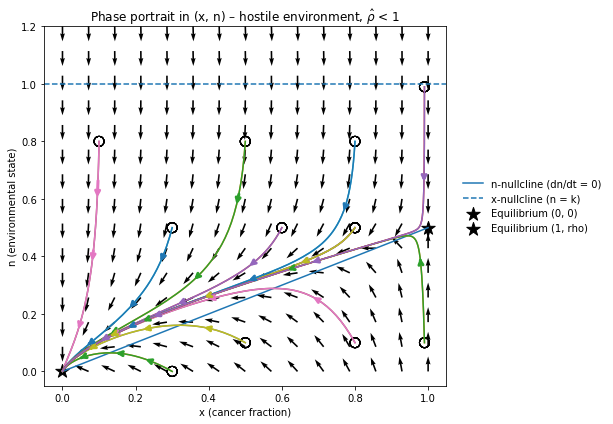

In [6]:
# -----------------------------
# Parameters for hostile scenario, ρ < k
# -----------------------------
alpha = 1.0   # >0
beta  = 1.0   # >0
k     = 1.0   # tolerance
epsilon = 0.5
mu      = 1.0

rho = epsilon / mu  # environmental load
print("rho =", rho, f"(should be < k={k} for hostile, sub-threshold regime)")


# -----------------------------
# Phase portrait: vector field
# -----------------------------
## state-space grid
x_vals = np.linspace(0.0, 1.0, 15)
n_max  = max(rho * 1.2, k * 1.2)
n_vals = np.linspace(0.0, n_max, 15)

X, N = np.meshgrid(x_vals, n_vals)

# compute vector field
f = make_rhs_hostile(alpha, beta, epsilon, mu, k)
U, V = f(0.0, (X, N))

# normalize arrows
speed = np.sqrt(U**2 + V**2)
speed[speed == 0] = 1.0
U_norm = U / speed
V_norm = V / speed

# plot vector field
fig, ax = plt.subplots(figsize=(8, 6))
ax.quiver(X, N, U_norm, V_norm, angles="xy")

# --------------------------------
# Nullclines
# --------------------------------
# n-nullcline: dn/dt = 0 -> n = rho * x
x_nc = np.linspace(0.0, 1.0, 200)
n_nc = rho * x_nc
ax.plot(x_nc, n_nc, label="n-nullcline (dn/dt = 0)")

# x-nullcline: dx/dt = 0 includes:
# x = 0, x = 1, and n = k (for interior x)
ax.axhline(k, linestyle="--", label="x-nullcline (n = k)")
# x=0 and x=1 are the boundaries of the domain, no extra line needed.


# --------------------------------
# Equilibria
# --------------------------------
# (0, 0): always an equilibrium, stable for rho < k in hostile scenario
ax.scatter([0.0], [0.0], 
            marker="*", 
            s=200, 
            color='k', 
            label="Equilibrium (0, 0)"
           )

# (1, rho): cancer boundary equilibrium (saddle here because rho < k)
ax.scatter([1.0], 
            [rho], 
            marker="*", 
            s=200, 
            color='k', 
            label="Equilibrium (1, rho)"
           )

# Threshold point (mu*k/epsilon, k) is outside x in [0,1] when rho < k,
# so we do not plot it here.


# --------------------------------
# Sample trajectories
# --------------------------------
# a few initial conditions in the biological region
initial_conditions = [
    (0.3, 0.0),
    (0.8, 0.5),
    (0.1, 0.8),
    (0.5, 0.1),
    (0.3, 0.5),
    (0.5, 0.8),
    (0.6, 0.5),
    (0.8, 0.1),
    (0.8, 0.5),
    (0.8, 0.8),
    (0.99, 0.1),
    (0.99, 0.99)
]

t_span = (0.0, 50.0)
t_eval = np.linspace(t_span[0], t_span[1], 500)

for x0, n0 in initial_conditions:
    f = make_rhs_hostile(alpha, beta, epsilon, mu, k)
    sol = solve_ivp(f, t_span, [x0, n0], t_eval=t_eval, dense_output=False)
    #plt.plot(sol.y[0], sol.y[1])
    x_traj, n_traj = sol.y
    (line,) = ax.plot(x_traj, n_traj)

    # plot trajectory and get Line2D handle
    (line,) = ax.plot(x_traj, n_traj)
    # add arrows along this trajectory
    add_arrows_to_line2D(line, n_arrows=3, lw=3)
    
    # Plot initial condition markers on top
    x0_list = [ic[0] for ic in initial_conditions]
    n0_list = [ic[1] for ic in initial_conditions]

    ax.scatter(
        x0_list, n0_list,
        marker="o",
        s=100,
        edgecolor="k",
        facecolor="none",
        #label="Initial conditions"
    )

# --------------------------------
# Formatting
# --------------------------------
ax.set_xlabel("x (cancer fraction)")
ax.set_ylabel("n (environmental state)")
ax.set_xlim(-0.05, 1.05)
ax.set_ylim(-0.05, n_max)
ax.set_title(r'Phase portrait in (x, n) – hostile environment, $\hat\rho$ < 1')

# leave space on the right
fig.tight_layout(rect=[0, 0, 0.8, 1])
# legend outside
ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=False)
#fig.savefig(f'Figures/hostile_rhohat<1.png', dpi=300)

plt.show()

### $\rho > k$

### Params

In [59]:
# -----------------------------
# Parameters for hostile scenario, ρ > k
# -----------------------------
alpha = 1.0   # >0
beta  = 1.0   # >0
k     = 1.0   # tolerance

epsilon = 2.0  # choose epsilon big so that rho > k
mu      = 1.0

rho = epsilon / mu  # environmental load
print("rho =", rho, "(should be > k for hostile, super-threshold regime)")

# --------------------------------
# Equilibria
# --------------------------------
x_healthy, n_healthy = 0.0, 0.0
x_cancer,  n_cancer  = 1.0, rho
x_saddle   = mu * k / epsilon  # = k / rho
n_saddle   = k

f = make_rhs_hostile(alpha, beta, epsilon, mu, k)

# -----------------------------
# Phase portrait: vector field
# -----------------------------
x_vals = np.linspace(0.0, 1.0, 15)
n_max  = max(rho * 1.2, k * 1.2)
n_vals = np.linspace(0.0, n_max, 15)

X, N = np.meshgrid(x_vals, n_vals)

U, V = f(0.0, (X, N))

# normalize arrows
speed = np.sqrt(U**2 + V**2)
speed[speed == 0] = 1.0
U_norm = U / speed
V_norm = V / speed

rho = 2.0 (should be > k for hostile, super-threshold regime)


### Stable manifold and basin

In [8]:
# ---------------------------
# Stable manifold from saddle
# ---------------------------
J = jac_hostile(x_saddle, n_saddle, alpha, beta, epsilon, mu, k)
eigvals, eigvecs = np.linalg.eig(J)

# stable eigenvector = eigenvector corresponding to negative eigenvalue
idx_stable = np.argmin(eigvals.real)  # smallest real part
v_stable = eigvecs[:, idx_stable].real
v_stable /= np.linalg.norm(v_stable)

# We start slightly off the saddle along ± stable direction
delta = 1e-3
y0_plus  = np.array([x_saddle, n_saddle]) + delta * v_stable
y0_minus = np.array([x_saddle, n_saddle]) - delta * v_stable

# Integrate backwards in time to trace the stable manifold
t_span = (0.0, -100.0)
t_eval = np.linspace(t_span[0], t_span[1], 2000)

sol_plus  = solve_ivp(f, t_span, y0_plus,  t_eval=t_eval, rtol=1e-8, atol=1e-10)
sol_minus = solve_ivp(f, t_span, y0_minus, t_eval=t_eval, rtol=1e-8, atol=1e-10)

# ---------------------------
# Basin plot (classification)
# ---------------------------
x_min, x_max = 0.0, 1.0
n_min, n_max = 0.0, max(rho * 1.2, k * 1.5)

Nx, Nn = 100, 100
xs = np.linspace(x_min, x_max, Nx)
ns = np.linspace(n_min, n_max, Nn)

basin = np.zeros((Nn, Nx), dtype=int)  # 0 = healthy, 1 = cancer

T_final = 80.0
for i, n0 in enumerate(ns):
    for j, x0 in enumerate(xs):
        sol = solve_ivp(f, (0.0, T_final), [x0, n0],
                        t_eval=[T_final], rtol=1e-6, atol=1e-9)
        xT, nT = sol.y[0, -1], sol.y[1, -1]
        d_healthy = np.hypot(xT - x_healthy, nT - n_healthy)
        d_cancer  = np.hypot(xT - x_cancer,  nT - n_cancer)
        basin[i, j] = 0 if d_healthy < d_cancer else 1

### Plot altogether

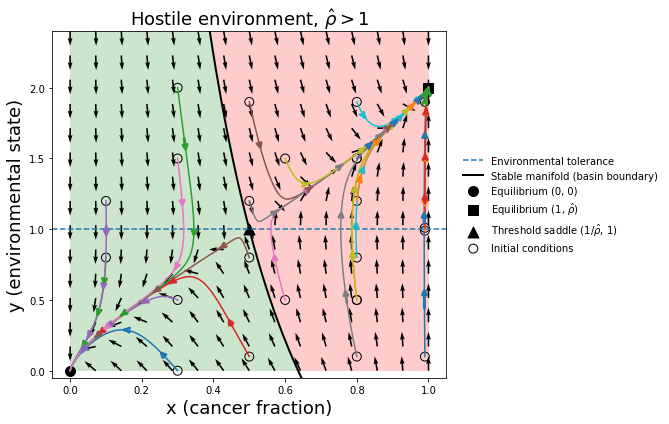

In [72]:
fig, ax = plt.subplots(figsize=(8, 6))

# --------------------------------
# Vector field
# --------------------------------
ax.quiver(X, N, U_norm, V_norm, angles="xy")

# --------------------------------
# Nullclines
# --------------------------------
# n-nullcline: dn/dt = 0 -> n = rho * x
x_nc = np.linspace(0.0, 1.0, 200)
n_nc = rho * x_nc
#ax.plot(x_nc, n_nc, label="n-nullcline (dn/dt = 0)")

# x-nullcline: dx/dt = 0 includes x=0, x=1, and n = k (for interior x)
ax.axhline(
    k,
    linestyle="--",
    label="Environmental tolerance"
)
# x = 0 and x = 1 are just the boundaries of the domain

ax.scatter(
    [x_healthy], [n_healthy],
    marker="o",
    s=100,
    color="k",
    label="Equilibrium (0, 0)"
)

ax.scatter(
    [x_cancer], [n_cancer],
    marker="s",
    s=100,
    color="k",
    label=r"Equilibrium (1, $\hat\rho$)"
)

ax.scatter(
    [x_saddle], [n_saddle],
    marker="^",
    s=120,
    color="k",
    label=r"Threshold saddle ($1/\hat\rho$, 1)"
)

# --------------------------------
# Sample trajectories to show basins
# --------------------------------
initial_conditions = [
    (0.3, 0.0),
    (0.8, 0.5),
    (0.1, 0.8),
    (0.5, 0.1),
    (0.3, 0.5),
    (0.5, 0.8),
    (0.6, 0.5),
    (0.8, 0.1),
    (0.8, 0.5),
    (0.8, 0.8),
    (0.99, 0.1),
    (0.99, 0.99),
    # reflect
    (0.3, 2.0),
    (0.8, 1.5),
    (0.1, 1.2),
    (0.5, 1.9),
    (0.3, 1.5),
    (0.5, 1.2),
    (0.6, 1.5),
    (0.8, 1.9),
    (0.8, 1.5),
    (0.8, 1.2),
    (0.99, 1.9),
    (0.99, 1.01),
]

t_span = (0.0, 50.0)
t_eval = np.linspace(t_span[0], t_span[1], 500)

for x0, n0 in initial_conditions:
    sol = solve_ivp(f, t_span, [x0, n0], t_eval=t_eval, dense_output=False)
    x_traj, n_traj = sol.y

    # plot trajectory and get Line2D handle
    (line,) = ax.plot(x_traj, n_traj)

    # add arrows along this trajectory
    add_arrows_to_line2D(line, n_arrows=3, lw=3)

# plot initial condition markers on top
x0_list = [ic[0] for ic in initial_conditions]
n0_list = [ic[1] for ic in initial_conditions]
ax.scatter(
    x0_list,
    n0_list,
    marker="o",
    s=80,
    edgecolor="k",
    facecolor="none",
    label="Initial conditions",
)

# ---------------------------
# Plot basin + stable manifold
# ---------------------------

# basins as background
cmap = mcolors.ListedColormap(["green", "red"])  # 0 -> green, 1 -> red
norm = mcolors.BoundaryNorm(boundaries=[-0.5, 0.5, 1.5], ncolors=cmap.N)
im = ax.imshow(
    basin,
    origin="lower",
    extent=[x_min, x_max, n_min, n_max],
    aspect="auto",
    alpha=0.2,
    cmap=cmap,
    norm=norm,
)

ax.plot(sol_plus.y[0],  sol_plus.y[1],  'k-', lw=2,
        label='Stable manifold (basin boundary)')
ax.plot(sol_minus.y[0], sol_minus.y[1], 'k-', lw=2)

# axes formatting
ax.set_xlim(x_min, x_max)
ax.set_ylim(n_min, n_max)

# --------------------------------
# Formatting
# --------------------------------
ax.set_xlabel("x (cancer fraction)", fontsize=18)
ax.set_ylabel("y (environmental state)", fontsize=18)
ax.set_xlim(-0.05, 1.05)
ax.set_ylim(-0.05, n_max)
ax.set_title(r"Hostile environment, $\hat\rho > 1$", fontsize=18)

# leave space on the right for legend
fig.tight_layout(rect=[0, 0, 0.8, 1])

# legend outside on the right
ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=False)

# optional save
#fig.savefig('Figures/hostile_rhohat>1.png', dpi=300)

# --------------------------------
# Inset
# --------------------------------
"""
# Inset axes (top-left). Tweak loc/bbox_to_anchor as needed.
axins = inset_axes(
    ax,
    width="38%", height="38%",
    loc="upper left",
    borderpad=1.0
)

# Parameter range for the inset
rhohat = np.linspace(0.2, 3.0, 600)

# Branches
x0 = np.zeros_like(rhohat)          # healthy equilibrium
x1 = np.ones_like(rhohat)           # cancer boundary equilibrium
xthr = 1.0 / rhohat                 # threshold saddle branch (exists only for rhohat > 1)

# Masks
m_lt = rhohat < 1.0
m_gt = rhohat > 1.0

# Plot equilibria: solid = stable, dashed = unstable/saddle (no custom colors)
axins.plot(rhohat, x0, lw=2.0, ls='-')                    # x*=0 stable for all rhohat
axins.plot(rhohat[m_lt], x1[m_lt], lw=2.0, ls='--')       # x*=1 saddle for rhohat<1
axins.plot(rhohat[m_gt], x1[m_gt], lw=2.0, ls='-')        # x*=1 stable for rhohat>1
axins.plot(rhohat[m_gt], xthr[m_gt], lw=2.0, ls='--')     # x*=1/rhohat saddle for rhohat>1

# Threshold marker
axins.axvline(1.0, lw=1.5, ls=':')

# Labels (kept minimal)
axins.set_title(r"Equilibria vs $\hat\rho$", fontsize=9)
axins.set_xlabel(r"$\hat\rho$", fontsize=9)
axins.set_ylabel(r"$x^\ast$", fontsize=9)

# Limits and tidy styling
axins.set_xlim(rhohat.min(), rhohat.max())
axins.set_ylim(-0.05, 1.05)
axins.tick_params(axis='both', which='both', labelsize=8, length=3)

# Optional: small annotations (comment out if you want it cleaner)
axins.text(0.25, 0.02, r"stable $x^\ast=0$", fontsize=8, transform=axins.transAxes)
axins.text(0.55, 0.86, r"$x^\ast=1$", fontsize=8, transform=axins.transAxes)
axins.text(0.55, 0.52, r"$x^\ast=1/\hat\rho$", fontsize=8, transform=axins.transAxes)
axins.text(0.62, 0.06, r"$\hat\rho=1$", fontsize=8, transform=axins.transAxes)
"""

plt.show()

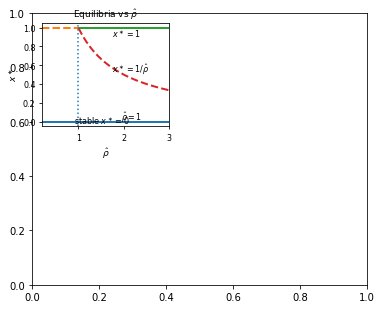

In [70]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# --- assume you already have fig, ax for your phase portrait ---
fig, ax = plt.subplots(figsize=(6,5))

# Inset axes (top-left). Tweak loc/bbox_to_anchor as needed.
axins = inset_axes(
    ax,
    width="38%", height="38%",
    loc="upper left",
    borderpad=1.0
)

# Parameter range for the inset
rhohat = np.linspace(0.2, 3.0, 600)

# Branches
x0 = np.zeros_like(rhohat)          # healthy equilibrium
x1 = np.ones_like(rhohat)           # cancer boundary equilibrium
xthr = 1.0 / rhohat                 # threshold saddle branch (exists only for rhohat > 1)

# Masks
m_lt = rhohat < 1.0
m_gt = rhohat > 1.0

# Plot equilibria: solid = stable, dashed = unstable/saddle (no custom colors)
axins.plot(rhohat, x0, lw=2.0, ls='-')                    # x*=0 stable for all rhohat
axins.plot(rhohat[m_lt], x1[m_lt], lw=2.0, ls='--')       # x*=1 saddle for rhohat<1
axins.plot(rhohat[m_gt], x1[m_gt], lw=2.0, ls='-')        # x*=1 stable for rhohat>1
axins.plot(rhohat[m_gt], xthr[m_gt], lw=2.0, ls='--')     # x*=1/rhohat saddle for rhohat>1

# Threshold marker
axins.axvline(1.0, lw=1.5, ls=':')

# Labels (kept minimal)
axins.set_title(r"Equilibria vs $\hat\rho$", fontsize=9)
axins.set_xlabel(r"$\hat\rho$", fontsize=9)
axins.set_ylabel(r"$x^\ast$", fontsize=9)

# Limits and tidy styling
axins.set_xlim(rhohat.min(), rhohat.max())
axins.set_ylim(-0.05, 1.05)
axins.tick_params(axis='both', which='both', labelsize=8, length=3)

# Optional: small annotations (comment out if you want it cleaner)
axins.text(0.25, 0.02, r"stable $x^\ast=0$", fontsize=8, transform=axins.transAxes)
axins.text(0.55, 0.86, r"$x^\ast=1$", fontsize=8, transform=axins.transAxes)
axins.text(0.55, 0.52, r"$x^\ast=1/\hat\rho$", fontsize=8, transform=axins.transAxes)
axins.text(0.62, 0.06, r"$\hat\rho=1$", fontsize=8, transform=axins.transAxes)

# If you want the inset to visually "float" without a busy frame:
# axins.set_facecolor("white")
# for spine in axins.spines.values():
#     spine.set_linewidth(1.0)
plt.show()


### 3. Stable coexistence

### $\rho < k$

In [33]:
# ---------------------------
# Parameters (coexistence, ρ < k)
# ---------------------------
alpha = 1.0
beta  = 1.0
k     = 1.0
epsilon = 0.5
mu      = 1.0

rho = epsilon / mu
print("rho =", rho, "(< k, coexistence regime)")

f = make_rhs_coexist(alpha, beta, epsilon, mu, k)

# ---------------------------
# x-nullcline curve n(x) for interior branch
# β ((n-k)/(n+k)) x + α(1-x) = 0  ->  n(x) as derived
# ---------------------------
def n_x_nullcline(x, alpha, beta, k):
    # avoid division problems:
    denom = alpha + x * (beta - alpha)
    # for x in (0,1) denom is positive for α,β>0, so we are safe there
    return -k * (alpha - x * (alpha + beta)) / denom

x_nc_curve = np.linspace(1e-3, 1 - 1e-3, 400)
n_nc_curve = n_x_nullcline(x_nc_curve, alpha, beta, k)

# ---------------------------
# Interior equilibrium (analytic via ρ < k branch I derived)
# ---------------------------
# From your explicit formula:
# x* = 2 α k / [ α(k-ρ) + β k + sqrt( (α(k-ρ)+βk)^2 + 4ρ(α-β)αk ) ]
# For α = β, this simplifies; but we'll just use the general form.
A = alpha * (k - rho) + beta * k
disc = A**2 + 4 * rho * (alpha - beta) * alpha * k  # = A^2 if α=β
x_star = 2 * alpha * k / (A + np.sqrt(disc))
n_star = rho * x_star

print("Interior equilibrium ~ (x*, n*) =", x_star, n_star)

# ---------------------------
# State-space grid and vector field
# ---------------------------
x_min, x_max = 0.0, 1.0
n_min, n_max = 0.0, max(rho * 1.3, k * 1.3)

x_vals = np.linspace(x_min, x_max, 15)
n_vals = np.linspace(n_min, n_max, 15)
X, N = np.meshgrid(x_vals, n_vals)

U = np.zeros_like(X)
V = np.zeros_like(N)

for i in range(X.shape[0]):
    for j in range(X.shape[1]):
        dx, dn = f(0.0, (X[i, j], N[i, j]))
        U[i, j] = dx
        V[i, j] = dn

speed = np.sqrt(U**2 + V**2)
speed[speed == 0] = 1.0
U_norm = U / speed
V_norm = V / speed

# ---------------------------
# Trajectories (a few sample ICs)
# ---------------------------
t_span = (0.0, 60.0)
t_eval = np.linspace(t_span[0], t_span[1], 800)

initial_conditions = [
    (0.3, 0.0),
    (0.8, 0.5),
    (0.1, 0.8),
    (0.5, 0.1),
    (0.3, 0.5),
    (0.5, 0.8),
    (0.6, 0.5),
    (0.8, 0.1),
    (0.8, 0.5),
    (0.8, 0.8),
    (0.99, 0.1),
    (0.99, 0.99)
]

rho = 0.5 (< k, coexistence regime)
Interior equilibrium ~ (x*, n*) = 0.6666666666666666 0.3333333333333333


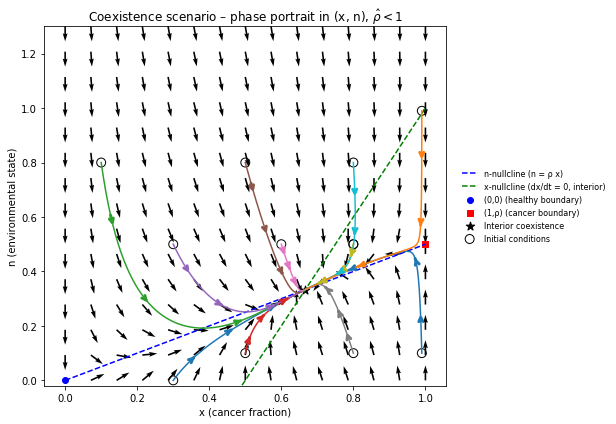

In [35]:
fig, ax = plt.subplots(figsize=(8, 6))

# -----------------------------
# Vector field
# -----------------------------
ax.quiver(X, N, U_norm, V_norm, angles="xy")

# -----------------------------
# Nullclines
# -----------------------------
# n-nullcline: n = ρ x
x_nc = np.linspace(0.0, 1.0, 200)
n_nc = rho * x_nc
ax.plot(x_nc, n_nc, "b--", label="n-nullcline (n = ρ x)")

# x-nullcline: interior branch n(x)
ax.plot(x_nc_curve, n_nc_curve, "g--", label="x-nullcline (dx/dt = 0, interior)")

# boundaries x = 0, x = 1 are also x-nullclines, but they are the domain edges.

# -----------------------------
# Equilibria
# -----------------------------
ax.scatter(
    [0.0],
    [0.0],
    c="blue",
    marker="o",
    label="(0,0) (healthy boundary)",
)

ax.scatter(
    [1.0],
    [rho],
    c="red",
    marker="s",
    label="(1,ρ) (cancer boundary)",
)

ax.scatter(
    [x_star],
    [n_star],
    c="black",
    marker="*",
    s=80,
    label="Interior coexistence",
)

# -----------------------------
# Trajectories
# -----------------------------
for x0, n0 in initial_conditions:
    sol = solve_ivp(f, t_span, [x0, n0], t_eval=t_eval, rtol=1e-8, atol=1e-10)
    x_traj, n_traj = sol.y

    # plot trajectory and get Line2D handle
    (line,) = ax.plot(x_traj, n_traj, lw=1.5)

    # add arrows along this trajectory
    add_arrows_to_line2D(line, n_arrows=3, lw=3)

# initial condition markers on top
x0_list = [ic[0] for ic in initial_conditions]
n0_list = [ic[1] for ic in initial_conditions]
ax.scatter(
    x0_list,
    n0_list,
    marker="o",
    s=80,
    edgecolor="k",
    facecolor="none",
    label="Initial conditions",
)

# -----------------------------
# Formatting
# -----------------------------
ax.set_xlabel("x (cancer fraction)")
ax.set_ylabel("n (environmental state)")
#ax.set_xlim(x_min - 0.02, x_max + 0.02)
ax.set_ylim(n_min - 0.02, n_max)
ax.set_title(r'Coexistence scenario – phase portrait in (x, n), $\hat\rho<1$')

# leave space on the right for legend
fig.tight_layout(rect=[0, 0, 0.8, 1])

# legend outside on the right
ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=False, fontsize=8)

# optional save
# fig.savefig("Figures/coexistence_rho<k.png", dpi=300)

plt.show()

### $\rho > k$

In [40]:
# ---------------------------
# Parameters (coexistence, ρ > k)
# ---------------------------
alpha = 1.0
beta  = 1.0
k     = 1.0
epsilon = 2.0   # choose ε > μ k -> ρ > k
mu      = 1.0

rho = epsilon / mu
print("rho =", rho, "(> k, coexistence: cancer-dominated regime)")

f = make_rhs_coexist(alpha, beta, epsilon, mu, k)

# ---------------------------
# x-nullcline interior branch n(x) (even if no intersection with n=ρx)
# β ((n-k)/(n+k)) x + α(1-x) = 0  ->  n(x)
# ---------------------------
def n_x_nullcline(x, alpha, beta, k):
    denom = alpha + x * (beta - alpha)
    return -k * (alpha - x * (alpha + beta)) / denom

x_nc_curve = np.linspace(1e-3, 1 - 1e-3, 400)
n_nc_curve = n_x_nullcline(x_nc_curve, alpha, beta, k)

# ---------------------------
# Equilibria
# ---------------------------
x_healthy, n_healthy = 0.0, 0.0        # saddle in coexistence scenario
x_cancer,  n_cancer  = 1.0, rho        # stable node for ρ > k

print("Healthy boundary:", (x_healthy, n_healthy))
print("Cancer attractor:", (x_cancer, n_cancer))

# Intersection of n = ρ x with tolerance line n = k (not an equilibrium, just a marker)
x_thresh = k / rho
n_thresh = k
print("Crossing of n=ρx with n=k:", (x_thresh, n_thresh))

# ---------------------------
# State-space grid and vector field
# ---------------------------
x_min, x_max = 0.0, 1.0
n_min, n_max = 0.0, max(rho * 1.3, k * 1.5)

x_vals = np.linspace(x_min, x_max, 25)
n_vals = np.linspace(n_min, n_max, 25)
X, N = np.meshgrid(x_vals, n_vals)

U = np.zeros_like(X)
V = np.zeros_like(N)

for i in range(X.shape[0]):
    for j in range(X.shape[1]):
        dx, dn = f(0.0, (X[i, j], N[i, j]))
        U[i, j] = dx
        V[i, j] = dn

speed = np.sqrt(U**2 + V**2)
speed[speed == 0] = 1.0
U_norm = U / speed
V_norm = V / speed

# ---------------------------
# A few trajectories
# ---------------------------
t_span = (0.0, 40.0)
t_eval = np.linspace(t_span[0], t_span[1], 600)
"""
initial_conditions = [
    (0.05, 0.05),
    (0.2, 0.1),
    (0.4, 0.2),
    (0.6, 0.8),
    (0.9, 0.3),
    (0.8, 1.5),
]
"""
initial_conditions = [
    (0.3, 0.0),
    (0.8, 0.5),
    (0.1, 0.8),
    (0.5, 0.1),
    (0.3, 0.5),
    (0.5, 0.8),
    (0.6, 0.5),
    (0.8, 0.1),
    (0.8, 0.5),
    (0.8, 0.8),
    (0.99, 0.1),
    (0.99, 0.99),
    # reflect
    (0.3, 2.0),
    (0.8, 1.5),
    (0.1, 1.2),
    (0.5, 1.9),
    (0.3, 1.5),
    (0.5, 1.2),
    (0.6, 1.5),
    (0.8, 1.9),
    (0.8, 1.5),
    (0.8, 1.2),
    (0.99, 1.9),
    (0.99, 1.01),
]

rho = 2.0 (> k, coexistence: cancer-dominated regime)
Healthy boundary: (0.0, 0.0)
Cancer attractor: (1.0, 2.0)
Crossing of n=ρx with n=k: (0.5, 1.0)


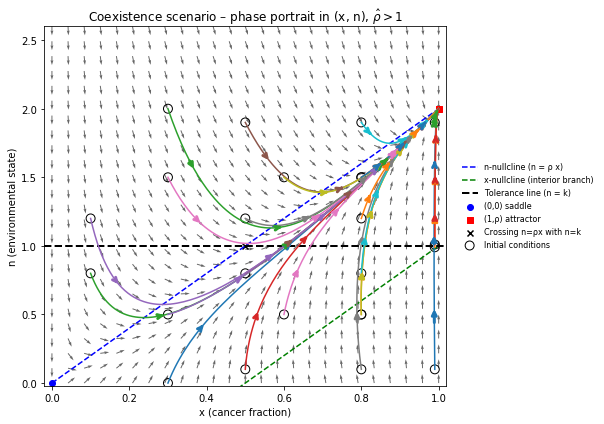

In [39]:
# ---------------------------
# Plotting
# ---------------------------
fig, ax = plt.subplots(figsize=(8, 6))

# vector field
ax.quiver(X, N, U_norm, V_norm, angles="xy", alpha=0.6)

# n-nullcline: n = ρ x
x_nc = np.linspace(0.0, 1.0, 200)
n_nc = rho * x_nc
ax.plot(x_nc, n_nc, "b--", label="n-nullcline (n = ρ x)")

# x-nullcline interior curve (where bracket in dx/dt = 0)
ax.plot(x_nc_curve, n_nc_curve, "g--", label="x-nullcline (interior branch)")

# tolerance line (not a nullcline here, but biologically meaningful)
ax.axhline(k, color="black", linestyle="--", linewidth=2, label="Tolerance line (n = k)")

# equilibria
ax.scatter(
    [x_healthy],
    [n_healthy],
    c="blue",
    marker="o",
    label="(0,0) saddle",
)

ax.scatter(
    [x_cancer],
    [n_cancer],
    c="red",
    marker="s",
    label="(1,ρ) attractor",
)

# marker where n = ρ x crosses n = k (dynamic threshold in n)
if 0.0 < x_thresh < 1.0:
    ax.scatter(
        [x_thresh],
        [n_thresh],
        c="black",
        marker="x",
        label="Crossing n=ρx with n=k",
    )

# trajectories
for x0, n0 in initial_conditions:
    sol = solve_ivp(
        f, t_span, [x0, n0],
        t_eval=t_eval,
        rtol=1e-8,
        atol=1e-10,
    )
    x_traj, n_traj = sol.y

    # plot trajectory and get Line2D handle
    (line,) = ax.plot(x_traj, n_traj, lw=1.5)

    # add arrows along this trajectory
    add_arrows_to_line2D(line, n_arrows=3, lw=3)

# initial condition markers on top
x0_list = [ic[0] for ic in initial_conditions]
n0_list = [ic[1] for ic in initial_conditions]
ax.scatter(
    x0_list,
    n0_list,
    marker="o",
    s=80,
    edgecolor="k",
    facecolor="none",
    label="Initial conditions",
)

# formatting
ax.set_xlabel("x (cancer fraction)")
ax.set_ylabel("n (environmental state)")
ax.set_xlim(x_min - 0.02, x_max + 0.02)
ax.set_ylim(n_min - 0.02, n_max)
ax.set_title(r'Coexistence scenario – phase portrait in (x, n), $\hat\rho>1$')

# leave space on the right for legend
fig.tight_layout(rect=[0, 0, 0.8, 1])

# legend outside on the right
ax.legend(
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=False,
    fontsize=8,
)

# optional save
# fig.savefig("Figures/coexistence_rho>k.png", dpi=300)

plt.show()


### Now, equilibrium depends on the values of $r$ and $\hat\rho$

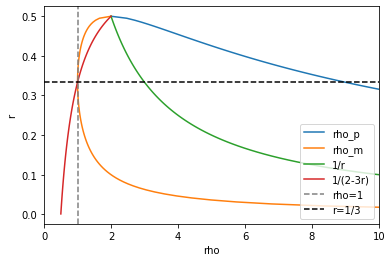

In [50]:
raux = np.linspace(0.001,0.5,100)
plt.plot(rho_p(raux),raux,label='rho_p')
plt.plot(rho_m(raux),raux,label='rho_m')
plt.plot(1/raux,raux,label="1/r")
plt.plot(1/(2-3*raux),raux,label="1/(2-3r)")
plt.axvline(1,linestyle="--", color='gray', label="rho=1")
plt.axhline(1/3,linestyle="--", color='black', label="r=1/3")
plt.ylabel('r')
plt.xlabel('rho')
plt.xlim(0,10
        )
plt.legend()
plt.show()

#print("rho_p")
#print(rho_p(raux))

#print("rho_m")
#print(rho_m(raux))

### Overlay theoretical contours on the heatmap

/Users/guillermo/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:24: RuntimeWarning: invalid value encountered in greater
/Users/guillermo/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:24: RuntimeWarning: invalid value encountered in less


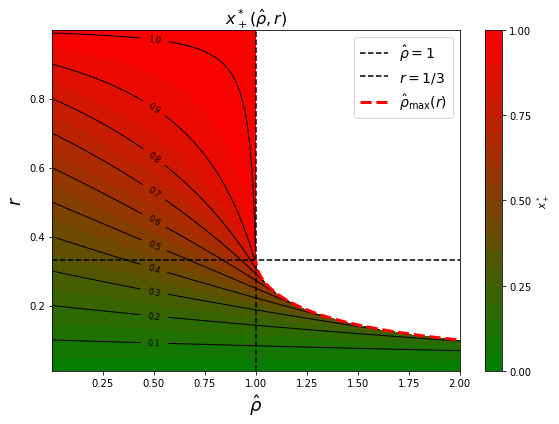

In [57]:
rho_min, rho_max = 1e-3, 2
r_min, r_max = 1e-2, 0.999
n = 400

manual_locations = [
    (1.8, 0.15),  # near the 0.1–0.2 contour
    (1.8, 0.25),
    (1.8, 0.35),
    (1.8, 0.45),
    (1.8, 0.55),
    (1.8, 0.65),
    (1.8, 0.75),
    (1.8, 0.85),
    (1.8, 0.95),
    (1.8, 0.98),
]

rho_vals = np.linspace(rho_min, rho_max, n)
r_vals = np.linspace(r_min, r_max, n)
RHO, R = np.meshgrid(rho_vals, r_vals)
Xstar = x_star_plus(RHO, R)

fig, ax = plt.subplots(figsize=(8,6))

#cf = ax.contourf(RHO, R, Xstar,
#                 levels=np.linspace(0,1,21),
#                 cmap='viridis')
#cbar = fig.colorbar(cf, ax=ax, label=r'$x^*_+$')



cmap = mcolors.LinearSegmentedColormap.from_list(
    "green_to_red", ["green", "red"], N=256
)

cf = ax.contourf(
    RHO, R, Xstar,
    levels=np.linspace(0, 1, 21),
    cmap=cmap,
    vmin=0, vmax=1,   # fixes the scale to [0,1]
)

cbar = fig.colorbar(cf, ax=ax, label=r"$x^*_+$")
cbar.set_ticks([0, 0.25, 0.5, 0.75, 1])  # optional




#"""
# Overlay selected level curves
cs = ax.contour(
    RHO, R, Xstar,
    levels=[0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 0.99],
    colors='black', linewidths=1
)

# --- choose label positions near the y-axis ---
x_label = rho_min + 0.5   # a bit to the right of the y-axis
manual_positions = []

for coll in cs.collections:          # one collection per level
    # gather all vertices of all paths for this level
    paths = coll.get_paths()
    verts = np.vstack([p.vertices for p in paths])
    # find vertex whose x is closest to x_label
    idx = np.argmin(np.abs(verts[:, 0] - x_label))
    manual_positions.append(tuple(verts[idx]))

# now label using these positions
ax.clabel(
    cs,
    fmt='%0.1f',
    fontsize=8,
    manual=manual_positions
)

#"""

# Overlay boundaries
ax.axvline(1.0, linestyle='--', color='k', label=r'$\hat{\rho}=1$')
ax.axhline(1/3, linestyle='--', color='k', label=r'$r=1/3$')
#ax.axhline(1/2, linestyle='--', color='k', label=r'$r=1/2$')

r_cap = np.linspace(r_min, 1/3, 200)
rho_cap_vals = rho_m(r_cap)#rho_cap(r_cap)
ax.plot(rho_cap_vals[56:], r_cap[56:], linestyle='--', color='red', linewidth=3, label=r'$\hat{\rho}_{\max}(r)$')

ax.set_xlabel(r'$\hat{\rho}$', fontsize=18)
ax.set_ylabel(r'$r$', fontsize=18)
ax.set_title(r'$x^*_+(\hat{\rho}, r)$', fontsize=16)
ax.legend(loc='upper right', fontsize=14)

plt.tight_layout()
plt.show()
